In [2]:
import pandas as pd
import numpy as np 

data = pd.read_csv("./data/clean_weather.csv", index_col=0)
data = data.ffill()
data

,tmax,tmin,rain,tmax_tomorrow
1970-01-01,60.0,35.0,0.0,52.0
1970-01-02,52.0,39.0,0.0,52.0
1970-01-03,52.0,35.0,0.0,53.0
1970-01-04,53.0,36.0,0.0,52.0
1970-01-05,52.0,35.0,0.0,50.0
...,...,...,...,...
2022-11-22,62.0,35.0,0.0,67.0
2022-11-23,67.0,38.0,0.0,66.0
2022-11-24,66.0,41.0,0.0,70.0
2022-11-25,70.0,39.0,0.0,62.0


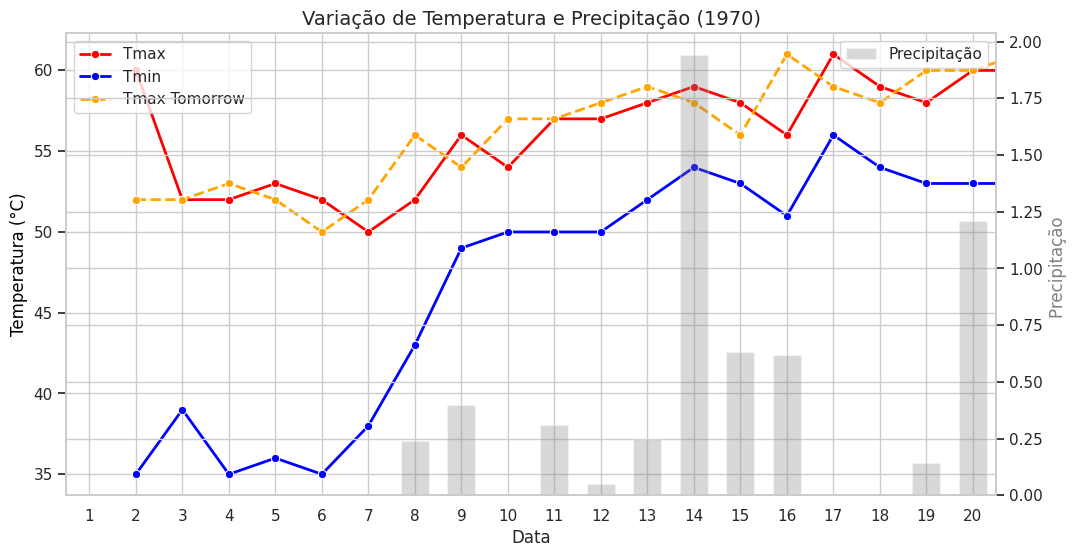

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = data.head(20)
df.index = pd.to_datetime(df.index)

# Estilo Seaborn
sns.set_theme(style="whitegrid")

# Criando a figura
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotando Tmax e Tmin como linhas
sns.lineplot(x=df.index.day, y=df["tmax"], ax=ax1, marker="o", label="Tmax", color="red", linewidth=2)
sns.lineplot(x=df.index.day, y=df["tmin"], ax=ax1, marker="o", label="Tmin", color="blue", linewidth=2)
sns.lineplot(x=df.index.day, y=df["tmax_tomorrow"], ax=ax1, marker="o", label="Tmax Tomorrow", color="orange", linestyle="dashed", linewidth=2)

# Criando um segundo eixo para a precipitação (rain)
ax2 = ax1.twinx()
sns.barplot(x=df.index.day, y=df["rain"], ax=ax2, color="gray", alpha=0.3, label="Precipitação", width=0.6)

# Ajustando os rótulos dos eixos
ax1.set_xlabel("Data", fontsize=12)
ax1.set_ylabel("Temperatura (°C)", fontsize=12, color="black")
ax2.set_ylabel("Precipitação ", fontsize=12, color="gray")

# Rotacionando os rótulos das datas
plt.xticks(rotation=45, fontsize=5)

# Adicionando legendas
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

# Título
plt.title("Variação de Temperatura e Precipitação (1970)", fontsize=14)
plt.savefig("data.svg", format="svg", dpi=600)
# Exibindo o gráfico
plt.show()


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Define predictors and target
PREDICTORS = ["tmax", "tmin", "rain"]
TARGET = "tmax_tomorrow"

# Scale our data to have mean 0
scaler = StandardScaler()
data[PREDICTORS] = scaler.fit_transform(data[PREDICTORS])

# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, random_state=0)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=0)

# Convertendo para arrays numpy
train_x = train_data[PREDICTORS].to_numpy()
train_y = train_data[[TARGET]].to_numpy()

x_val = valid_data[PREDICTORS].to_numpy()
y_val = valid_data[[TARGET]].to_numpy()

x_test = test_data[PREDICTORS].to_numpy()
y_test = test_data[[TARGET]].to_numpy()


In [11]:
import matplotlib.pyplot as plt
import keras

def compile_model(model, epochs=100):
    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Treinando o modelo
    history = model.fit(train_x, train_y, epochs=epochs, validation_data=(x_val, y_val), verbose=False)

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test)
    print(f"Teste MSE: {mse_t:.4f}")

    # Plotando o histórico de treinamento
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()


In [7]:
model_RNA = keras.models.Sequential([
        keras.layers.Flatten(input_shape=[3, 1]),
        keras.layers.Dense(1)
])
model_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(1, input_shape=[3, 1])
])

complex_RNN = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[3, 1]),
        keras.layers.SimpleRNN(20, return_sequences=True),
        keras.layers.SimpleRNN(1)
])

complex_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(20, return_sequences=True, input_shape=[3, 1]),
        keras.layers.SimpleRNN(20),
        keras.layers.Dense(1)
])

simple_dense_RNN  = keras.models.Sequential([
        keras.layers.SimpleRNN(1, return_sequences=True, input_shape=[3, 1]),
        keras.layers.Dense(1)
])

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4313.7871  
Validation MSE: 4305.7285
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4293.4785  
Teste MSE: 4285.5522


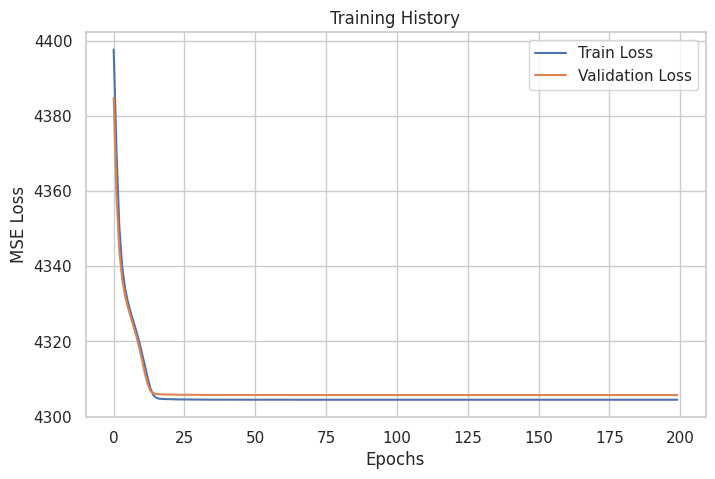

In [21]:
compile_model(model_RNN)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step - loss: 101.1133
Validation MSE: 101.8660
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - loss: 106.2637
Teste MSE: 102.8403


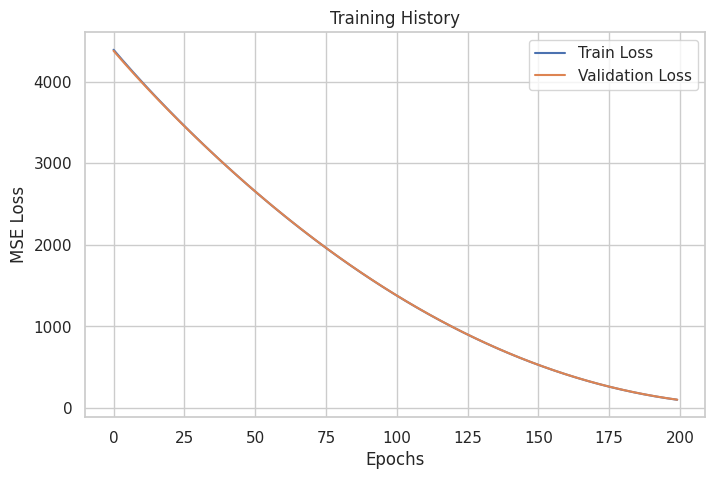

In [22]:
compile_model(model_RNA)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4313.7871
Validation MSE: 4305.7285
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4293.4785
Teste MSE: 4285.5522


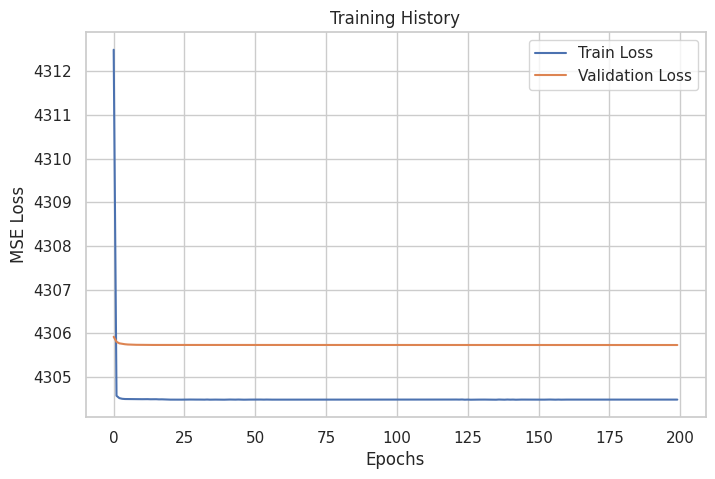

In [23]:
compile_model(complex_RNN)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.1677
Validation MSE: 21.6910
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.0341
Teste MSE: 22.7385


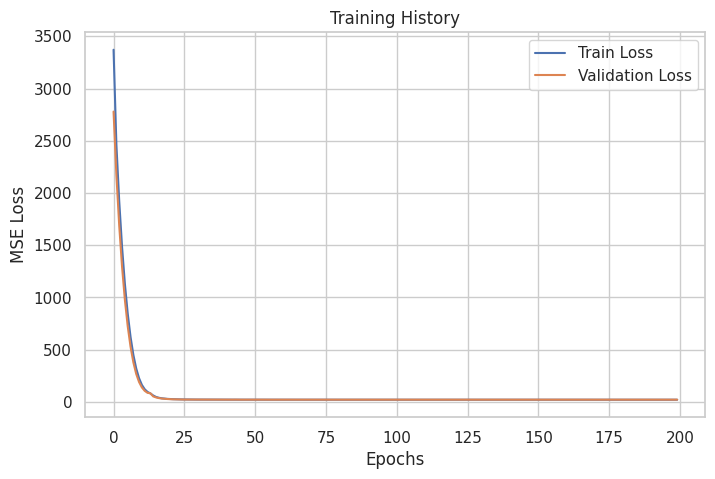

In [24]:
compile_model(complex_dense_RNN)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 57.4577  
Validation MSE: 58.1671
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 57.9987  
Teste MSE: 58.6069


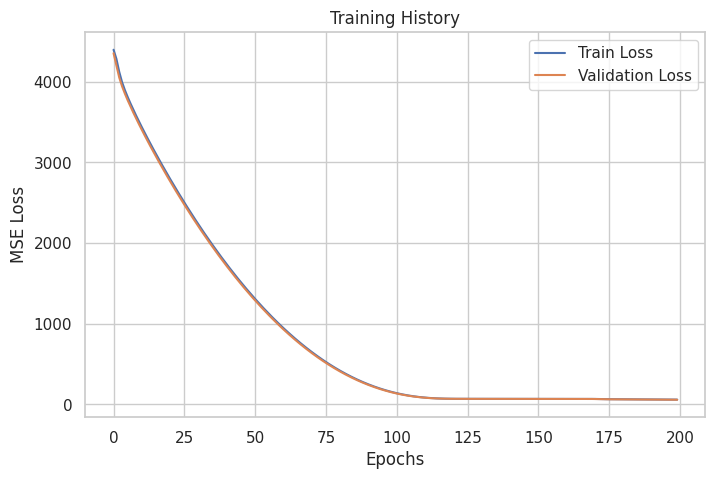

In [8]:
compile_model(simple_dense_RNN)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 31.6621  
Validation MSE: 31.8932
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 32.8468
Teste MSE: 32.8237


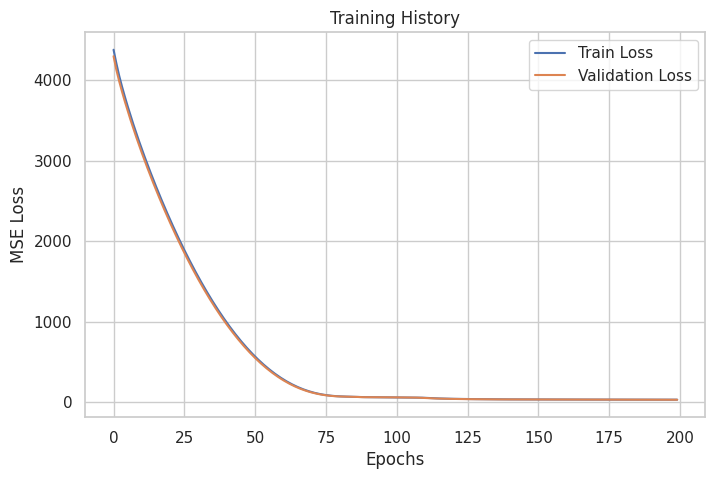

In [9]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(2, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.4856
Validation MSE: 22.3970
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.5482  
Teste MSE: 23.3493


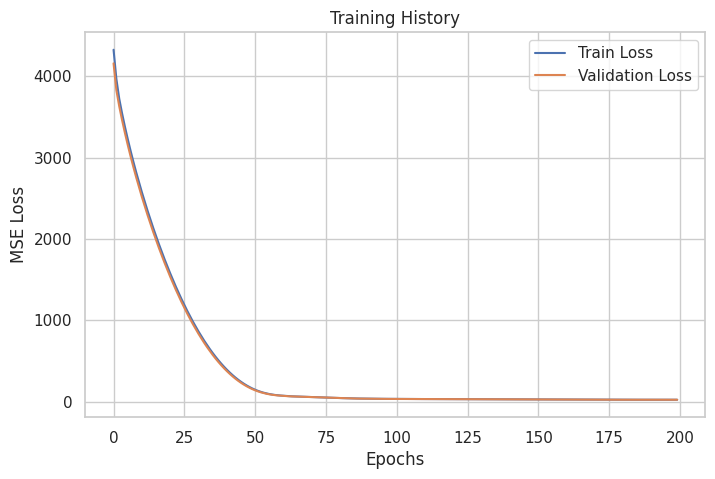

In [10]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(3, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.8038  
Validation MSE: 25.1381
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 25.6108
Teste MSE: 26.0979


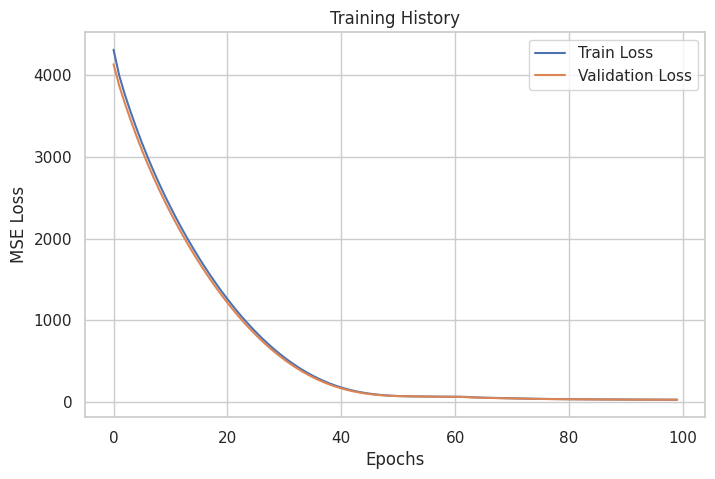

In [12]:
simple_dense_RNN  = keras.models.Sequential([
            keras.layers.SimpleRNN(4, return_sequences=True, input_shape=[3, 1]),
            keras.layers.Dense(1)
    ])
compile_model(simple_dense_RNN)